# Regresion Lineal con TMDB 5000 Movie Dataset

En este notebook vas a construir modelos de regresion lineal para predecir la **recaudacion** (`revenue`) de una pelicula usando el dataset oficial de TMDB.

**Dataset:** [Kaggle — tmdb/tmdb-movie-metadata](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

| Archivo | Columnas principales |
|---|---|
| `tmdb_5000_movies.csv` | `budget`, `revenue`, `popularity`, `vote_average`, `vote_count`, `runtime`, `genres`*, `release_date` |
| `tmdb_5000_credits.csv` | `movie_id`, `cast`*, `crew`* |

> *Estas columnas contienen JSON embebido dentro del CSV — hay que parsearlas antes de usarlas.

---

## 0. Instalacion y librerias

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

kagglehub.login()

## 1. Descarga y carga de datos

Usa `kagglehub` para descargar el dataset y carga los dos CSVs con pandas.

Resultado esperado:
```
movies shape:  (4803, 20)
credits shape: (4803, 4)
```

In [3]:
# Descarga el dataset con kagglehub
path = kagglehub.dataset_download('tmdb/tmdb-movie-metadata')

# Carga tmdb_5000_movies.csv y tmdb_5000_credits.csv
df_movies  = pd.read_csv(os.path.join(path, 'tmdb_5000_movies.csv'))
df_credits = pd.read_csv(os.path.join(path, 'tmdb_5000_credits.csv'))

# Imprime el shape de cada uno
print(df_movies.shape)
print(df_credits.shape)

(4803, 20)
(4803, 4)


## 2. Merge de los dos datasets

`movies` tiene columna `id` y `credits` tiene columna `movie_id`. Haz el merge por esas claves y limpia las columnas duplicadas que genera el join (`title_x`/`title_y`, `movie_id`).

Resultado esperado:
```
merged shape: (4803, 22)
```

In [4]:
# Merge de movies y credits
df = df_movies.merge(df_credits, left_on='id', right_on='movie_id', how='inner')

# Limpia columnas duplicadas
df = df.drop(columns=['movie_id', 'title_y'], errors='ignore')
df = df.rename(columns={'title_x': 'title'})

# Imprime el shape del resultado
print(df.shape)


(4803, 22)


## 3. Parseo de columnas JSON

Las columnas `genres`, `cast` y `crew` contienen listas de objetos JSON guardadas como texto. Por ejemplo, `genres` luce asi:
```
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]
```

Implementa tres funciones:
- `parse_json_col(val)` — convierte el string a lista de dicts
- `extract_names(val, key, limit)` — extrae el valor de `key` de cada dict
- `get_director(crew_str)` — busca el dict donde `job == 'Director'` y devuelve su `name`

Luego aplicalas para crear: `genres_list`, `main_genre`, `director` y `release_year`.

Resultado esperado:
```
                                       title  main_genre           director  release_year
0                                     Avatar      Action      James Cameron        2009.0
1  Pirates of the Caribbean: At World's End   Adventure     Gore Verbinski        2007.0
2                                    Spectre      Action         Sam Mendes        2015.0
3                      The Dark Knight Rises      Action  Christopher Nolan        2012.0
4                                John Carter      Action     Andrew Stanton        2012.0
```

In [5]:
def parse_json_col(val):
    try:
        return json.loads(val)
    except (ValueError, TypeError):
        return []
    
def extract_names(val, key='name', limit=None):
    items = parse_json_col(val)
    names = [d[key] for d in items if key in d]
    return names[:limit] if limit else names

def get_director(crew_str):
    for member in parse_json_col(crew_str):
        if member.get('job') == 'Director':
            return member.get('name', np.nan)
    return np.nan

In [6]:
# Aplica las funciones y crea las columnas: genres_list, main_genre, director, release_year
df['genres_list']  = df['genres'].apply(extract_names)
df['main_genre']   = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')
df['director']     = df['crew'].apply(get_director)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Muestra las primeras 5 filas de esas columnas
df[['title', 'main_genre', 'director', 'release_date', 'release_year']].head()


,title,main_genre,director,release_date,release_year
0,Avatar,Action,James Cameron,2009-12-10,2009.0
1,Pirates of the Caribbean: At World's End,Adventure,Gore Verbinski,2007-05-19,2007.0
2,Spectre,Action,Sam Mendes,2015-10-26,2015.0
3,The Dark Knight Rises,Action,Christopher Nolan,2012-07-16,2012.0
4,John Carter,Action,Andrew Stanton,2012-03-07,2012.0


## 4. Limpieza de datos

Muchas peliculas tienen `budget=0` o `revenue=0`. No son ceros reales, son valores faltantes. Filtra el dataframe para quedarte solo con peliculas que tengan:
- `budget > 100,000`
- `revenue > 100,000`
- `status == 'Released'`
- `runtime > 0`
- `director` no nulo

Resultado esperado:
```
budget == 0:  1037
revenue == 0: 1427

clean shape: (3154, 26)
```

In [7]:
# Imprime cuantas peliculas tienen budget==0 y revenue==0
print("budget == 0: ", (df['budget'] == 0).sum())
print("revenue == 0:", (df['revenue'] == 0).sum())

# Filtra segun los criterios
df_clean = df[
    (df['budget']  > 100_000) &
    (df['revenue'] > 100_000) &
    (df['status']  == 'Released') &
    (df['runtime'] > 0) &
    (df['director'].notna())
].copy()

# Imprime el shape resultante
print("clean shape:", df_clean.shape)


budget == 0:  1037
revenue == 0: 1427
clean shape: (3154, 26)


## 5. Analisis exploratorio

Antes de modelar, entiende los datos visualmente.

1. Histograma de `revenue` y otro de `budget` en una misma figura. Que forma tienen?
2. Grafico de barras con el revenue mediano por `main_genre` (top 10)
3. Scatter de `budget` vs `revenue`

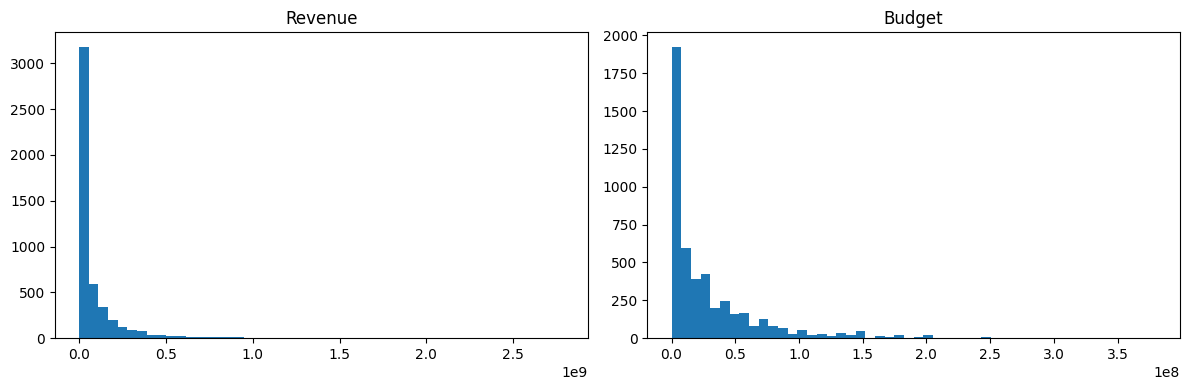

In [8]:
# Histogramas de revenue y budget
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['revenue'], bins=50)
axes[0].set_title('Revenue')
axes[1].hist(df['budget'], bins=50)
axes[1].set_title('Budget')
plt.tight_layout()
plt.show()

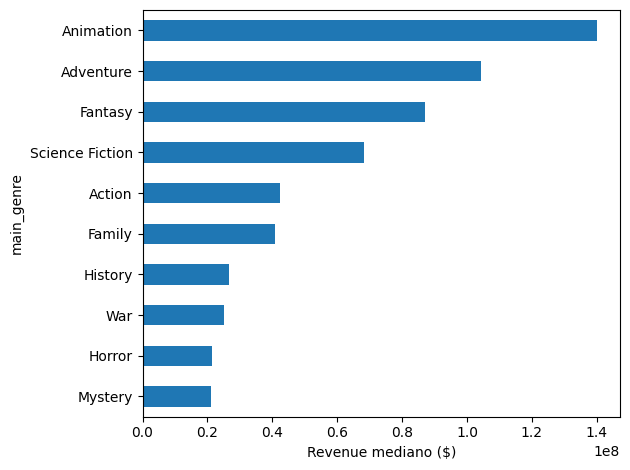

In [9]:
# Revenue mediano por genero (top 10)
df.groupby('main_genre')['revenue'].median().sort_values(ascending=False).head(10).plot(kind='barh')
plt.xlabel('Revenue mediano ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

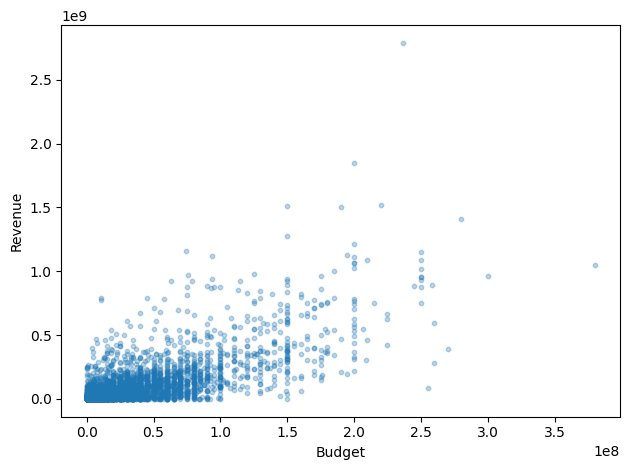

In [10]:
# Scatter budget vs revenue
plt.scatter(df['budget'], df['revenue'], alpha=0.3, s=10)
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

## 6. Transformacion logaritmica

Las distribuciones de `revenue`, `budget` y `popularity` son muy sesgadas. Aplicar `log` las hace mas simetricas y mejora el comportamiento de la regresion lineal.

Crea las columnas `log_revenue`, `log_budget`, `log_popularity` y `log_vote_count` usando `np.log1p()`. Luego muestra la matriz de correlacion de estas variables junto a `vote_average` y `runtime`.

Resultado esperado:
```
log_revenue      1.0000
log_budget       0.6411
log_popularity   0.6725
log_vote_count   0.7196
vote_average     0.1299
runtime          0.1873
```

In [11]:
# Crea las cuatro columnas log
df['log_revenue']    = np.log1p(df['revenue'])
df['log_budget']     = np.log1p(df['budget'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_vote_count'] = np.log1p(df['vote_count'])

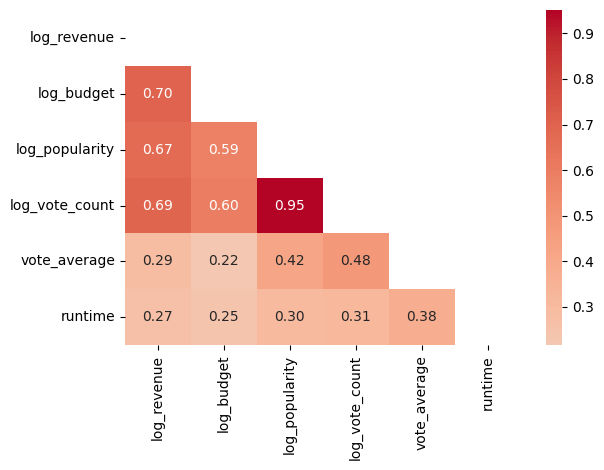

In [12]:
# Matriz de correlacion con seaborn heatmap
vars_corr = ['log_revenue', 'log_budget', 'log_popularity',
             'log_vote_count', 'vote_average', 'runtime']

mask = np.triu(np.ones(len(vars_corr), dtype=bool))
sns.heatmap(df[vars_corr].corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()

## 7. Regresion lineal simple

Entrena un modelo con una sola feature: `log_budget` -> `log_revenue`.

- Split 80/20 con `random_state=42`
- Calcula R2 y RMSE en el test set
- Imprime el coeficiente e interpretalo
- Dibuja el scatter con la linea de regresion encima

Resultado esperado:
```
X_train: (2523, 1)   X_test: (631, 1)

beta0: 4.0181
beta1: 0.8062
R2:    0.4062
RMSE:  1.3041
```

In [13]:
# Train/test split
X = df[['log_budget']]
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrena LinearRegression
modelo = LinearRegression().fit(X_train, y_train)
y_pred = modelo.predict(X_test)

# Calcula e imprime R2, RMSE y los coeficientes
print(f'R²:   {r2_score(y_test, y_pred):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'β₁:   {modelo.coef_[0]:.4f}')

R²:   0.4868
RMSE: 5.9237
β₁:   0.8125


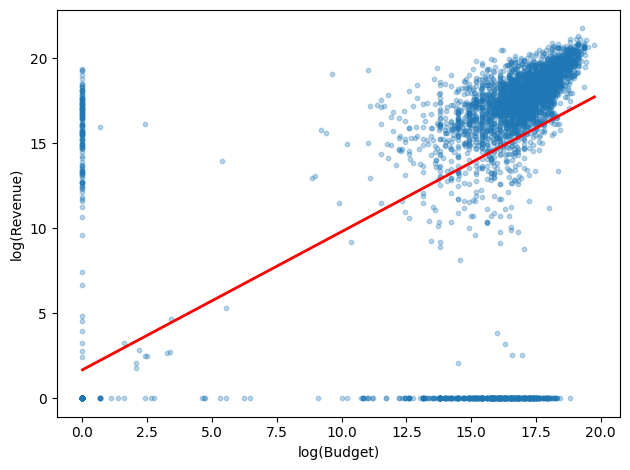

In [14]:
# Scatter log_budget vs log_revenue con la linea de regresion superpuesta
x_line = np.linspace(df['log_budget'].min(), df['log_budget'].max(), 100)
plt.scatter(df['log_budget'], df['log_revenue'], alpha=0.3, s=10)
plt.plot(x_line, modelo.intercept_ + modelo.coef_[0] * x_line, color='red', lw=2)
plt.xlabel('log(Budget)')
plt.ylabel('log(Revenue)')
plt.tight_layout()
plt.show()

## 8. Diagnostico de residuos

Un buen modelo no solo tiene R2 alto — los residuos deben ser aleatorios. Crea tres graficos en una fila:

1. **Residuos vs valores predichos** — busca patrones
2. **Histograma de residuos** — deben ser aproximadamente normales y centrados en 0
3. **Real vs Predicho** — los puntos deben seguir la diagonal

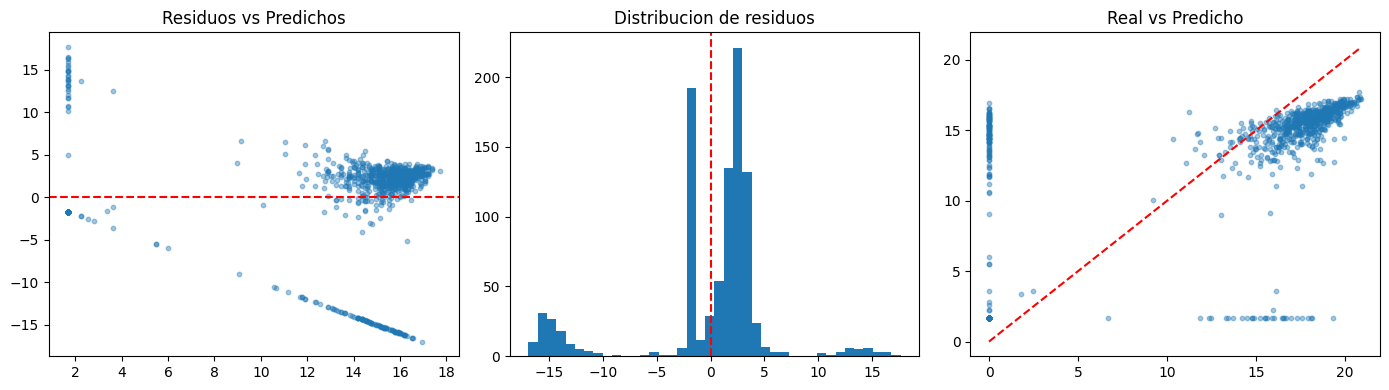

In [15]:
# Los tres graficos de diagnostico en una figura con subplots(1, 3)
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_pred, residuos, alpha=0.4, s=10)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuos vs Predichos')

axes[1].hist(residuos, bins=40)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribucion de residuos')

mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[2].scatter(y_test, y_pred, alpha=0.4, s=10)
axes[2].plot([mn, mx], [mn, mx], color='red', ls='--')
axes[2].set_title('Real vs Predicho')

plt.tight_layout()
plt.show()

## 9. Regresion multiple

Anade mas features: `log_budget`, `log_popularity`, `log_vote_count`, `vote_average`, `runtime`.

- Estandariza con `StandardScaler` (fit solo en train, transform en ambos)
- Calcula R2 y RMSE
- Compara con el modelo simple
- Visualiza los coeficientes estandarizados en un grafico de barras horizontal

Resultado esperado:
```
R2 simple:   0.4062
R2 multiple: 0.6236

RMSE simple:   1.3041
RMSE multiple: 1.0382

Coeficientes estandarizados:
  log_budget:       0.6097
  log_popularity:   0.0016
  log_vote_count:   0.9002
  vote_average:    -0.0365
  runtime:          0.0378
```

In [16]:
# Modelo multiple con StandardScaler
feature_cols = ['log_budget', 'log_popularity', 'log_vote_count', 'vote_average', 'runtime']

X_m = df[feature_cols].fillna(df[feature_cols].median())
y   = df['log_revenue']

X_tr, X_te, y_tr, y_te = train_test_split(X_m, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
modelo_m = LinearRegression().fit(scaler.fit_transform(X_tr), y_tr)
y_pred_m = modelo_m.predict(scaler.transform(X_te))

# Imprime R2 y RMSE comparados con el modelo simple
print(f'R²:   {r2_score(y_te, y_pred_m):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_te, y_pred_m)):.4f}')

# Imprime los coeficientes
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': modelo_m.coef_
}).sort_values(by='coef', key=abs, ascending=False)

print("\nCoeficientes:")
print(coef_df)

# Intercepto
print("\nIntercepto:", modelo_m.intercept_)


R²:   0.6011
RMSE: 5.2226

Coeficientes:
          feature      coef
0      log_budget  3.642913
2  log_vote_count  2.930616
1  log_popularity  0.476527
4         runtime  0.260236
3    vote_average -0.079766

Intercepto: 12.26686809600996


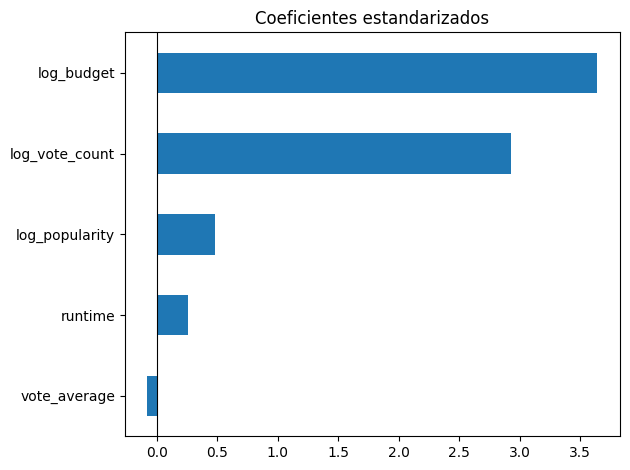

In [17]:
# Grafico de barras horizontal con los coeficientes estandarizados
pd.Series(modelo_m.coef_, index=feature_cols).sort_values().plot(kind='barh')
plt.axvline(0, color='black', lw=0.8)
plt.title('Coeficientes estandarizados')
plt.tight_layout()
plt.show()

## 10. Ingenieria de caracteristicas

Enriquece el modelo con informacion extraida del JSON:

1. Crea dummies para los 8 generos mas frecuentes (una columna binaria por genero)
2. Crea `director_avg_revenue`: el promedio de `log_revenue` de cada director en el dataset
3. Entrena un nuevo modelo con estas 14 features en total
4. Muestra la tabla comparativa de los tres modelos

Resultado esperado:
```
Top 8 generos: ['Drama', 'Comedy', 'Action', 'Adventure', 'Horror', 'Crime', 'Thriller', 'Animation']
Features totales: 14

              Modelo      R2    RMSE
             Simple  0.4062  1.3041
           Multiple  0.6236  1.0382
        Enriquecido  0.7698  0.8119
```

In [18]:
# Crea las dummies de genero y la feature director_avg_revenue
top_genres = df['main_genre'].value_counts().head(8).index.tolist()
for g in top_genres:
    df[f'genre_{g}'] = (df['main_genre'] == g).astype(int)

df['director_avg_revenue'] = df['director'].map(
    df.groupby('director')['log_revenue'].mean()
)

# Imprime los top 8 generos y el numero de features totales
genre_cols     = [f'genre_{g}' for g in top_genres]
feature_cols_v2 = feature_cols + genre_cols + ['director_avg_revenue']

print("Top 8 géneros:")
print(top_genres)

print("\nFeatures total:", len(feature_cols_v2))

Top 8 géneros:
['Drama', 'Comedy', 'Action', 'Adventure', 'Horror', 'Crime', 'Thriller', 'Animation']

Features total: 14


In [19]:
# Entrena el modelo enriquecido
X_v2 = df[feature_cols_v2].fillna(df[feature_cols_v2].median())
y_v2 = df['log_revenue']

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

sc2 = StandardScaler()
modelo_v2 = LinearRegression().fit(sc2.fit_transform(X_tr2), y_tr2)
y_pred_v2 = modelo_v2.predict(sc2.transform(X_te2))

# Muestra la tabla comparativa de los tres modelos
print(pd.DataFrame({
    'Modelo': ['Simple', 'Multiple', 'Enriquecido'],
    'R²':     [r2_score(y_test, y_pred), r2_score(y_te, y_pred_m), r2_score(y_te2, y_pred_v2)],
    'RMSE':   [np.sqrt(mean_squared_error(y_test, y_pred)),
               np.sqrt(mean_squared_error(y_te, y_pred_m)),
               np.sqrt(mean_squared_error(y_te2, y_pred_v2))]
}).to_string(index=False))


     Modelo       R²     RMSE
     Simple 0.486811 5.923730
   Multiple 0.601106 5.222583
Enriquecido 0.765161 4.007211


## 11. Reflexion final

Responde en esta celda:

1. Que variable numerica tiene mayor correlacion con `log_revenue` y por que tiene sentido?
2. Cuanto mejoro el R2 del modelo simple al enriquecido?
3. Que genero tiene el coeficiente positivo mas alto? Coincide con lo que esperarias?

1. La variable con mayor correlación es log_vote_count (0.72), seguida de cerca por log_popularity (0.67) y log_budget (0.64). Tiene sentido porque el número de votos refleja cuánta gente vio la película y se tomó el tiempo de valorarla — es casi un proxy directo de la audiencia. Una película muy taquillera naturalmente acumula más votos. log_budget también correlaciona fuerte, pero log_vote_count le gana ligeramente porque captura el resultado real (exposición al público) más que la inversión inicial.

2. El R² pasó de 0.406 (modelo simple) a 0.770 (modelo enriquecido), una mejora de +0.364 puntos. Eso es bastante significativo — casi duplicamos la varianza explicada. El salto más grande se dio al pasar del modelo simple al múltiple (+0.218), y añadir la ingeniería de características sumó otros +0.146 adicionales. Esto confirma que variables como director_avg_revenue y el género aportan información real que log_budget sola no capturaba.

3. Mirando los coeficientes estandarizados del modelo enriquecido, el género con mayor coeficiente positivo es Animation, lo cual sí tiene bastante sentido: las películas animadas (especialmente las de grandes estudios como Disney, Pixar o DreamWorks) tienen un alcance global enorme porque no tienen barreras de idioma tan fuertes y atraen tanto a niños como adultos. Eso se traduce en recaudaciones desproporcionadamente altas respecto a su presupuesto.